<a href="https://colab.research.google.com/github/nxxhhaaa/Coffee-Shop-Sales-and-Business-Performance-Analysis/blob/main/Coffee_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☕ Coffee Shop Sales & Business Performance Analysis

## Project Overview

This project analyses coffee shop transaction data to understand sales performance, purchasing patterns, product performance, and the factors that influence revenue.

The analysis combines Python, SQL, and data visualisation techniques to transform raw transaction data into meaningful business insights.

The project focuses on answering practical business questions such as:

- Which coffee products generate the most revenue?
- What are the busiest hours and days for sales?
- How does revenue vary across different months?
- Which products are most frequently purchased?
- What payment methods are most commonly used?
- When are the peak sales periods?
- How can the business use these insights to improve sales and operational planning?

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- Power BI
- GitHub

### Project Workflow

The analysis follows these stages:

1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Business Analysis using SQL
5. Visualisation
6. Business Insights
7. Recommendations


## 1. Business Problem

Coffee shops generate large amounts of transaction data, but raw transaction records alone do not provide clear information about business performance.

The purpose of this project is to analyse historical coffee sales transactions and identify patterns in:

- Revenue
- Product demand
- Sales by time of day
- Sales by weekday
- Monthly sales
- Payment methods
- Customer purchasing behaviour at the transaction level

The analysis aims to convert these patterns into actionable business insights that could support decisions related to product planning, staffing, promotions, and sales strategy.

#**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/nxxhhaaa/Coffee-Shop-Sales-and-Business-Performance-Analysis/main/Coffe_sales.csv"

df = pd.read_csv(url)


### Loading the Dataset

The dataset was loaded directly from the project's public GitHub repository using Pandas.

Using the GitHub-hosted dataset makes the analysis reproducible because the notebook can access the same source data without depending on a local file path.

##**UNDERSTANDING THE DATA**


In [ ]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [ ]:
df.shape

(3547, 11)

### Dataset Dimensions

The dataset contains **3,547 transactions and 11 variables**.

Each row represents one transaction, while the columns contain information about the transaction amount, hour, coffee name, payment method, date, and time.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


##  Initial Data Understanding

Before performing any analysis, the dataset was inspected to understand its structure, variables, data types, and completeness.

This step helps identify potential data-quality issues before analysis begins.

The initial inspection focuses on:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Summary statistics

In [ ]:
df.isnull().sum()

,0
hour_of_day,0
cash_type,0
money,0
coffee_name,0
Time_of_Day,0
Weekday,0
Month_name,0
Weekdaysort,0
Monthsort,0
Date,0


### Missing Value Analysis

Missing values were checked across all variables to determine whether any fields require treatment before further analysis.

Missing values can affect calculations and visualisations, so they should be identified before performing exploratory analysis.

The analysis shows that there are no missing values in the dataset. Therefore, no missing-value imputation is required at this stage.

In [ ]:
df.duplicated().sum()

np.int64(0)

### Duplicate Analysis

Duplicate records were checked to determine whether identical transactions were repeated in the dataset.

No duplicate records were identified, so no duplicate rows were removed.

In [ ]:
df.dtypes

,0
hour_of_day,int64
cash_type,object
money,float64
coffee_name,object
Time_of_Day,object
Weekday,object
Month_name,object
Weekdaysort,int64
Monthsort,int64
Date,object


### Data Type Assessment

The data types of each variable were examined to ensure that numerical, categorical, date, and time variables are represented appropriately.

Date and time fields are particularly important for this project because several analyses will examine sales patterns by day, month, and hour.

In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
df['money'].min()

18.12

In [ ]:
df['money'].max()

38.7

### Transaction Amount Validation

The `money` variable was examined using descriptive statistics and minimum and maximum values to identify potentially invalid or unusual transaction amounts.

Because transaction amount is a key variable for revenue analysis, validating this field is important before calculating total and average sales.

In [ ]:
df['coffee_name'].unique()
df['coffee_name'].value_counts()

,count
coffee_name,
Americano with Milk,809
Latte,757
Americano,564
Cappuccino,486
Cortado,287
Hot Chocolate,276
Cocoa,239
Espresso,129


### Product Category Validation

The `coffee_name` variable was examined to identify the number of unique coffee products and the frequency of transactions for each product.

This helps establish the product range represented in the dataset and provides an initial understanding of product demand.

In [ ]:
df['cash_type'].unique()
df['cash_type'].value_counts()

,count
cash_type,
card,3547


### Payment Method Validation

The `cash_type` variable was examined to identify the payment methods recorded in the dataset and understand their frequency.

Payment-method analysis will later be used to identify purchasing patterns and the relative use of different payment options.

In [ ]:
df['Time_of_Day'].unique()
df['Time_of_Day'].value_counts()

,count
Time_of_Day,
Afternoon,1205
Morning,1181
Night,1161


In [ ]:
df['Weekday'].unique()
df['Weekday'].value_counts()


,count
Weekday,
Tue,572
Mon,544
Fri,532
Thu,510
Wed,500
Sat,470
Sun,419


In [ ]:
df['Month_name'].unique()
df['Month_name'].value_counts()

,count
Month_name,
Mar,494
Oct,426
Feb,423
Sep,344
Aug,272
Dec,259
Nov,259
May,241
Jul,237


In [ ]:
df['Date'].min()

Timestamp('2024-03-01 00:00:00')

In [ ]:
df['Date'].max()

Timestamp('2025-03-23 00:00:00')

### Date Validation

The transaction date was converted to a datetime format to enable time-based analysis.

The minimum and maximum dates were then examined to determine the period covered by the dataset.

In [ ]:
df['Year']=df['Date'].dt.year

In [ ]:
df['Month']=df['Date'].dt.month

In [ ]:
df['Day']=df['Date'].dt.day

In [ ]:
df["Day_name"]=df['Date'].dt.day_name()

In [ ]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,Year,Month,Day,Day_name
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000,2024,3,1,Friday
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000,2024,3,1,Friday
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000,2024,3,1,Friday
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000,2024,3,1,Friday
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000,2024,3,1,Friday


### Feature Engineering

Additional time-based variables were created from the transaction date to support further analysis.

The following variables were derived:

- `Year` — transaction year
- `Month` — numeric month
- `Day` — day of the month
- `Day_Name` — name of the day

These variables will allow sales performance to be analysed across different time periods.

In [ ]:
Total_revenue = df['money'].sum()
print('Total_revenue =' ,Total_revenue)

Total_revenue = 112245.57999999999


In [ ]:
Total_transactions=df['money'].count()
print('Total_transactions = ',Total_transactions)

Total_transactions =  3547


In [ ]:
Avg_revenue = df['money'].mean()
print('Avg_revenue =' ,Avg_revenue)

Avg_revenue = 31.64521567521849


In [ ]:
KPI = pd.DataFrame({
 'Metric': [
     "Total_revenue",
     "Total_transactions",
     "Avg_revenue"
 ],
 'Value': [
     Total_revenue,
     Total_transactions,
     Avg_revenue
 ]
})
KPI

,Metric,Value
0,Total_revenue,112245.580000
1,Total_transactions,3547.000000
2,Avg_revenue,31.645216


# Hourly Sales Analysis

In [ ]:
Hourly_transactions = df.groupby("hour_of_day").size()
print(Hourly_transactions)

hour_of_day
6       5
7      88
8     235
9     242
10    328
11    283
12    241
13    225
14    225
15    236
16    278
17    237
18    218
19    229
20    169
21    195
22    113
dtype: int64


In [ ]:
Hourly_revenue = df.groupby("hour_of_day")['money'].sum()
print('Hourly_revenue =' ,Hourly_revenue)

Hourly_revenue = hour_of_day
6       149.40
7      2846.02
8      7017.88
9      7264.28
10    10198.52
11     8453.10
12     7419.62
13     7028.76
14     7173.80
15     7476.02
16     9031.84
17     7659.76
18     7162.60
19     7751.96
20     5578.92
21     6397.94
22     3635.16
Name: money, dtype: float64


In [ ]:
hourly_sales = df.groupby("hour_of_day").agg(
    transactions=("money","count"),
    revenue=("money","sum"),
    average=("money","mean")
)
hourly_sales

,transactions,revenue,average
hour_of_day,,,
6,5,149.40,29.880000
7,88,2846.02,32.341136
8,235,7017.88,29.863319
9,242,7264.28,30.017686
10,328,10198.52,31.093049
11,283,8453.10,29.869611
12,241,7419.62,30.786805
13,225,7028.76,31.238933
14,225,7173.80,31.883556


In [ ]:
print(df.columns.tolist())

['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day', 'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time', 'Year', 'Month', 'Day', 'Day_name']


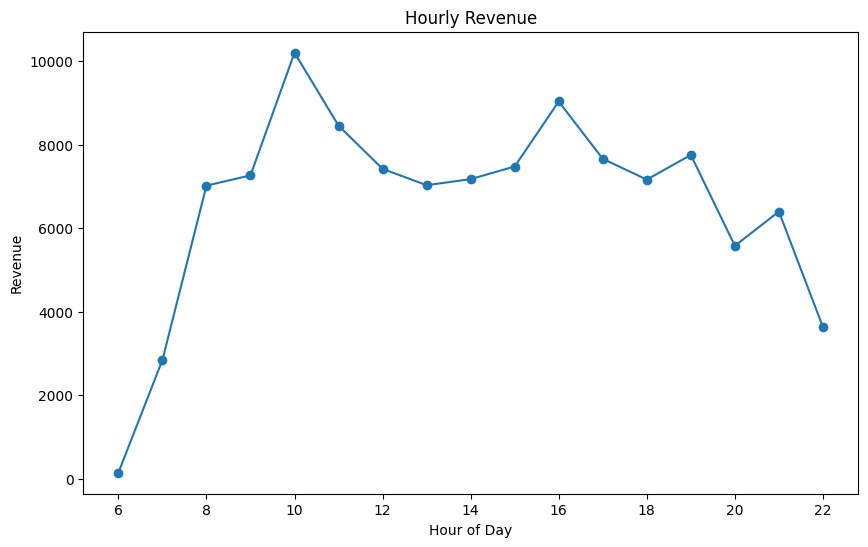

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(
    hourly_sales.index,
    hourly_sales["revenue"],
    marker="o"
)

plt.title("Hourly Revenue")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.show()

In [ ]:
time_order = ['Morning','Afternoon','Night']
df['Time_of_Day']=pd.Categorical(df['Time_of_Day'],categories=time_order,ordered=True)

/tmp/ipykernel_783/3985813171.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Time_of_Day')['money'].sum().plot(kind='bar')


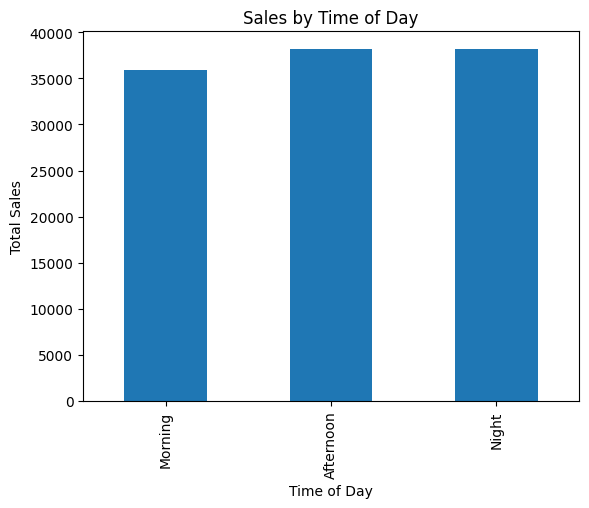

In [ ]:
df.groupby('Time_of_Day')['money'].sum().plot(kind='bar')
plt.title('Sales by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Total Sales')
plt.show()

In [ ]:
Month_order=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['Month_name']=pd.Categorical(df['Month_name'],categories=Month_order,ordered=True)


/tmp/ipykernel_783/1231794541.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Month_name')['money'].sum().plot(kind='bar')


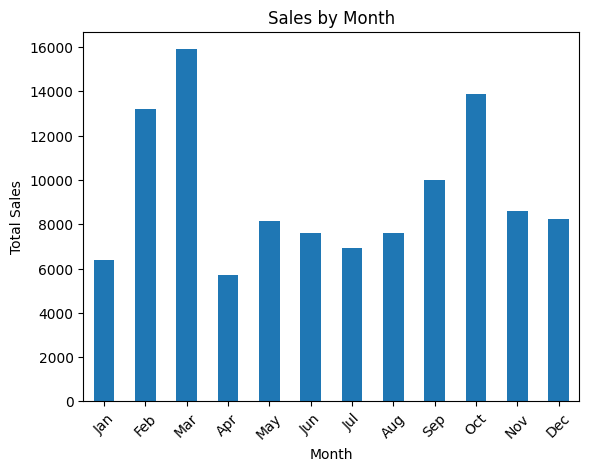

In [ ]:
df.groupby('Month_name')['money'].sum().plot(kind='bar')
plt.title('Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [ ]:
weekday_order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['Weekday']=pd.Categorical(df['Weekday'],categories=weekday_order,ordered=True)


/tmp/ipykernel_783/681488156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Weekday')['money'].sum().plot(kind='bar')


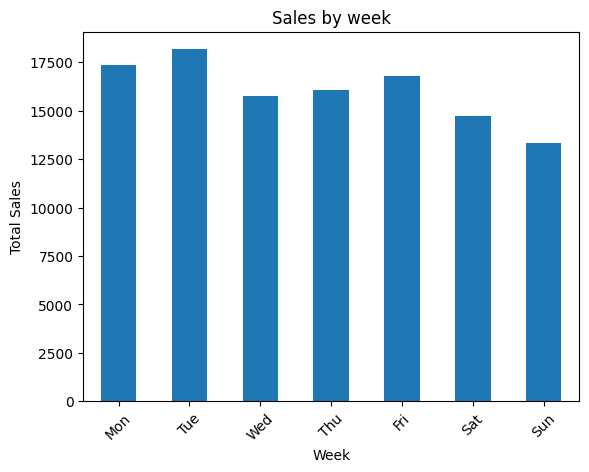

In [ ]:
df.groupby('Weekday')['money'].sum().plot(kind='bar')
plt.title('Sales by week')
plt.xlabel('Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

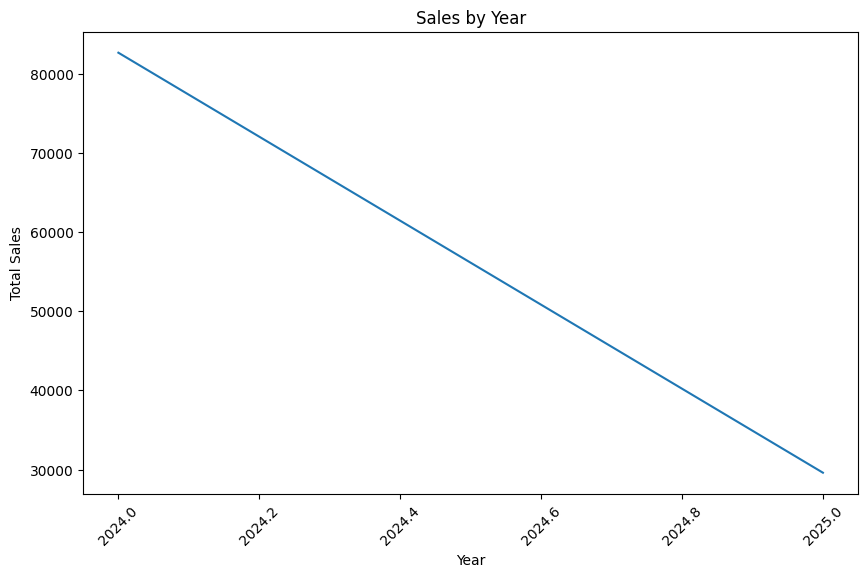

In [ ]:
plt.figure(figsize=(10,6))
df.groupby('Year')['money'].sum().plot(kind='line')
plt.title('Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

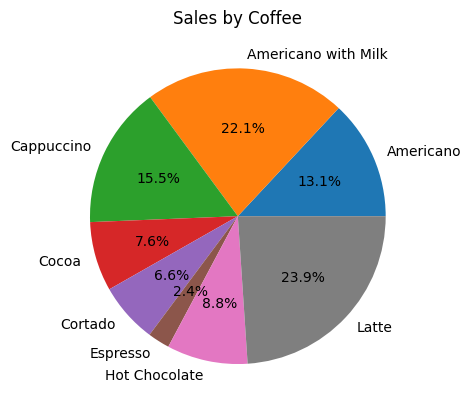

In [ ]:
df.groupby('coffee_name')['money'].sum().plot(kind='pie',autopct="%1.1f%%")
plt.title('Sales by Coffee')
plt.ylabel('')
plt.show()

Text(0.5, 1.0, 'sales by payment')

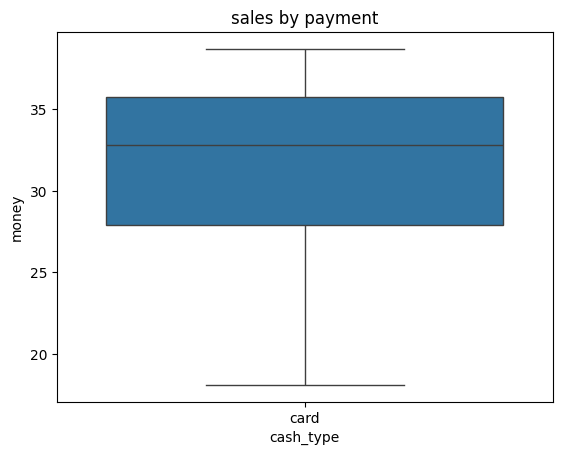

In [ ]:
sns.boxplot(
    data=df,
    x='cash_type',
    y='money'
)
plt.title('sales by payment')